In [ ]:
import os, glob, numpy as np, matplotlib.pyplot as plt
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.models as models
from sklearn.metrics import roc_curve, auc, roc_auc_score, classification_report, confusion_matrix
import seaborn as sns
from tqdm import tqdm

In [ ]:
!pip install gdown -q
import gdown

# Paste the FULL URL from the test instructions here
url = 'https://drive.google.com/file/d/1ZEyNMEO43u3qhJAwJeBZxFBEYc_pVYZQ/view'
gdown.download(url, '/content/dataset.zip', quiet=False, fuzzy=True)

Downloading...
From (original): https://drive.google.com/uc?id=1ZEyNMEO43u3qhJAwJeBZxFBEYc_pVYZQ
From (redirected): https://drive.google.com/uc?id=1ZEyNMEO43u3qhJAwJeBZxFBEYc_pVYZQ&confirm=t&uuid=ae26ed8a-8c20-4ad1-8b5e-db5afe955358
To: /content/dataset.zip
100%|██████████| 1.13G/1.13G [00:27<00:00, 40.6MB/s]


'/content/dataset.zip'

In [ ]:
!unzip -q /content/dataset.zip -d /content/dataset_fresh

In [ ]:
base = '/content/dataset_fresh/dataset'
for split in ['train', 'val']:
    print(f"\n{split}/")
    split_path = os.path.join(base, split)
    for cls in sorted(os.listdir(split_path)):
        cls_path = os.path.join(split_path, cls)
        if os.path.isdir(cls_path):
            count = len([f for f in os.listdir(cls_path) if f.endswith('.npy')])
            print(f"  {cls}/  ->  {count} .npy files")


train/
  no/  ->  10000 .npy files
  sphere/  ->  10000 .npy files
  vort/  ->  10000 .npy files

val/
  no/  ->  2500 .npy files
  sphere/  ->  2500 .npy files
  vort/  ->  2500 .npy files


In [ ]:
DATA_DIR = '/content/dataset_fresh/dataset'
BATCH_SIZE = 64
EPOCHS = 25
LEARNING_RATE = 3e-4
NUM_CLASSES = 3

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

class_names = ['no', 'sphere', 'vort']
class_map = {name: i for i, name in enumerate(class_names)}
idx2class = {i: name for name, i in class_map.items()}
print(f"Class mapping: {class_map}")

Using device: cuda
Class mapping: {'no': 0, 'sphere': 1, 'vort': 2}


no: shape=(1, 150, 150), dtype=float64, min=0.0000, max=1.0000
sphere: shape=(1, 150, 150), dtype=float64, min=0.0000, max=1.0000
vort: shape=(1, 150, 150), dtype=float64, min=0.0000, max=1.0000


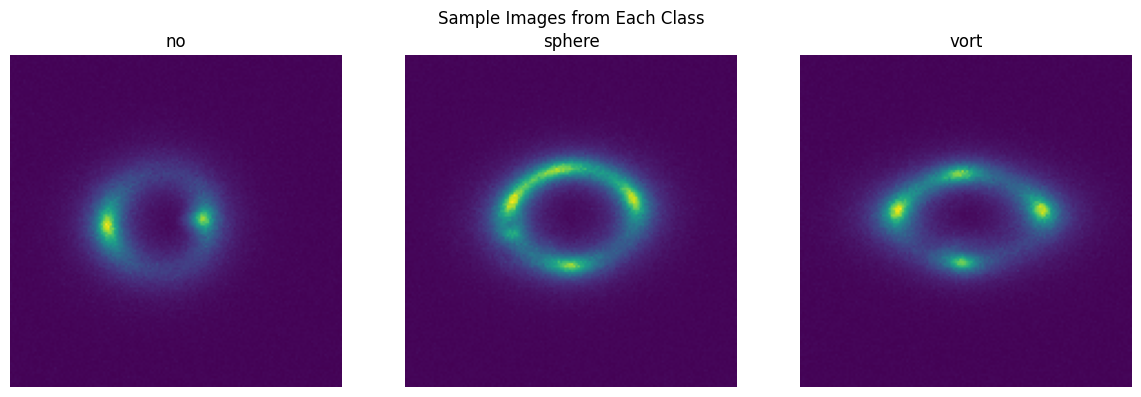

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, cls in enumerate(class_names):
    cls_path = os.path.join(DATA_DIR, 'train', cls)
    files = os.listdir(cls_path)
    img = np.load(os.path.join(cls_path, files[0]), allow_pickle=True)
    print(f"{cls}: shape={img.shape}, dtype={img.dtype}, min={img.min():.4f}, max={img.max():.4f}")
    if img.ndim == 3:
        img = img[0]
    axes[i].imshow(img, cmap='viridis')
    axes[i].set_title(cls)
    axes[i].axis('off')
plt.suptitle('Sample Images from Each Class')
plt.tight_layout()
plt.show()

In [ ]:

class LensingDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.data = []
        self.transform = transform

        # Combine both train and val folders
        for split in ['train', 'val']:
            for cls_name in class_names:
                cls_path = os.path.join(root_dir, split, cls_name)
                files = sorted(glob.glob(os.path.join(cls_path, '*.npy')))
                for f in files:
                    self.data.append((f, class_map[cls_name]))

        print(f"Total samples loaded: {len(self.data)}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, label = self.data[idx]
        img = np.load(img_path, allow_pickle=True)

        if img.ndim == 3:
            img = img[0]

        img = img.astype(np.float32)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        if self.transform:
            aug = self.transform(image=img)
            img = aug['image']
        else:
            img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)

        img = img.float()
        return img, label

In [ ]:
!pip install albumentations -q

import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=180, p=0.5),
    A.GaussNoise(var_limit=(0.001, 0.005), p=0.3),
    ToTensorV2()
])

val_transform = A.Compose([
    ToTensorV2()
])

# Load ALL data (train + val combined)
full_dataset = LensingDataset(DATA_DIR)

# 90:10 split
val_size = int(len(full_dataset) * 0.1)
train_size = len(full_dataset) - val_size

train_subset, val_subset = random_split(
    full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"90:10 split -> Train: {len(train_subset)}, Val: {len(val_subset)}")

# Wrapper to apply different transforms to train vs val
class TransformSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img_path, label = self.subset.dataset.data[self.subset.indices[idx]]
        img = np.load(img_path, allow_pickle=True)
        if img.ndim == 3:
            img = img[0]
        img = img.astype(np.float32)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        if self.transform:
            aug = self.transform(image=img)
            img = aug['image']
        else:
            img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
        img = img.float()
        return img, label

train_set = TransformSubset(train_subset, train_transform)
val_set = TransformSubset(val_subset, val_transform)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Verify
batch_imgs, batch_labels = next(iter(train_loader))
print(f"Batch shape: {batch_imgs.shape}, Labels: {batch_labels[:8]}")

/tmp/ipykernel_4245/3612417015.py:10: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(0.001, 0.005), p=0.3),


Total samples loaded: 37500
90:10 split -> Train: 33750, Val: 3750
Batch shape: torch.Size([64, 1, 150, 150]), Labels: tensor([0, 0, 0, 0, 2, 2, 0, 1])


In [ ]:

class LensClassifier(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.backbone.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

model = LensClassifier(NUM_CLASSES).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 147MB/s]


Model parameters: 11,171,779


In [ ]:

def calculate_accuracy(y_pred, y_truth):
    _, y_pred_labels = torch.max(y_pred, dim=1)
    correct = (y_pred_labels == y_truth).float()
    return correct.sum() / len(correct) * 100

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    losses, accs = [], []
    for imgs, labels in tqdm(loader, desc='Train', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        accs.append(calculate_accuracy(outputs, labels).item())
    return np.mean(losses), np.mean(accs)

def validate(model, loader, criterion):
    model.eval()
    losses, accs = [], []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc='Val', leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            losses.append(loss.item())
            accs.append(calculate_accuracy(outputs, labels).item())
    return np.mean(losses), np.mean(accs)

In [ ]:
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=1, eta_min=1e-6)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = validate(model, val_loader, criterion)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} Acc: {train_acc:.1f}% | Val Loss: {val_loss:.4f} Acc: {val_acc:.1f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"  -> Saved best model (val_acc={val_acc:.1f}%)")

print(f"\nBest validation accuracy: {best_val_acc:.1f}%")

Epoch 1/25 | Train Loss: 1.1400 Acc: 33.5% | Val Loss: 1.0956 Acc: 32.8%
  -> Saved best model (val_acc=32.8%)


Epoch 2/25 | Train Loss: 0.9592 Acc: 48.3% | Val Loss: 0.7755 Acc: 64.9%
  -> Saved best model (val_acc=64.9%)


Epoch 3/25 | Train Loss: 0.7155 Acc: 64.3% | Val Loss: 0.4265 Acc: 83.5%
  -> Saved best model (val_acc=83.5%)


Epoch 4/25 | Train Loss: 0.6238 Acc: 68.5% | Val Loss: 0.3391 Acc: 87.1%
  -> Saved best model (val_acc=87.1%)


Epoch 5/25 | Train Loss: 0.5776 Acc: 70.6% | Val Loss: 0.3659 Acc: 87.0%


...

Epoch 21/25 | Train Loss: 0.5022 Acc: 73.7% | Val Loss: 0.2058 Acc: 92.5%


Epoch 22/25 | Train Loss: 0.4956 Acc: 74.0% | Val Loss: 0.2059 Acc: 92.6%


Epoch 23/25 | Train Loss: 0.4892 Acc: 74.3% | Val Loss: 0.2213 Acc: 91.6%


Epoch 24/25 | Train Loss: 0.4805 Acc: 74.4% | Val Loss: 0.2309 Acc: 91.4%


Epoch 25/25 | Train Loss: 0.4708 Acc: 75.1% | Val Loss: 0.1621 Acc: 94.0%

Best validation accuracy: 95.3%


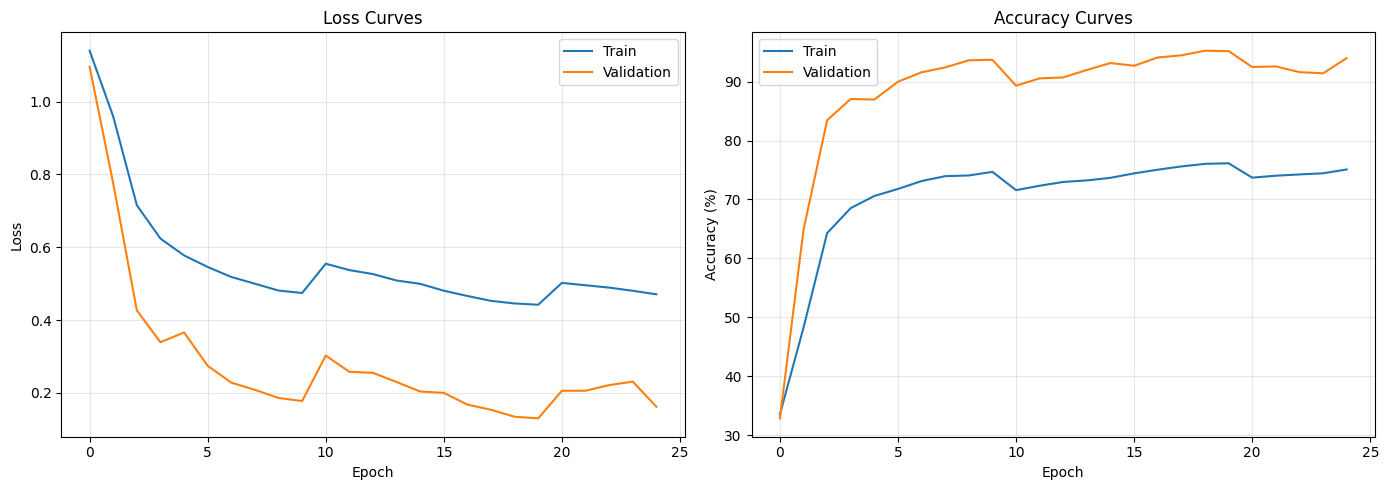

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['val_loss'], label='Validation')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Loss Curves'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history['train_acc'], label='Train')
ax2.plot(history['val_acc'], label='Validation')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy Curves'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Evaluating: 100%|██████████| 59/59 [00:02<00:00, 26.89it/s]


AUC SCORES
Macro-average OVR ROC-AUC: 0.9936
Macro-average OVO ROC-AUC: 0.9935
Weighted-average OVR ROC-AUC: 0.9936
Weighted-average OVO ROC-AUC: 0.9936


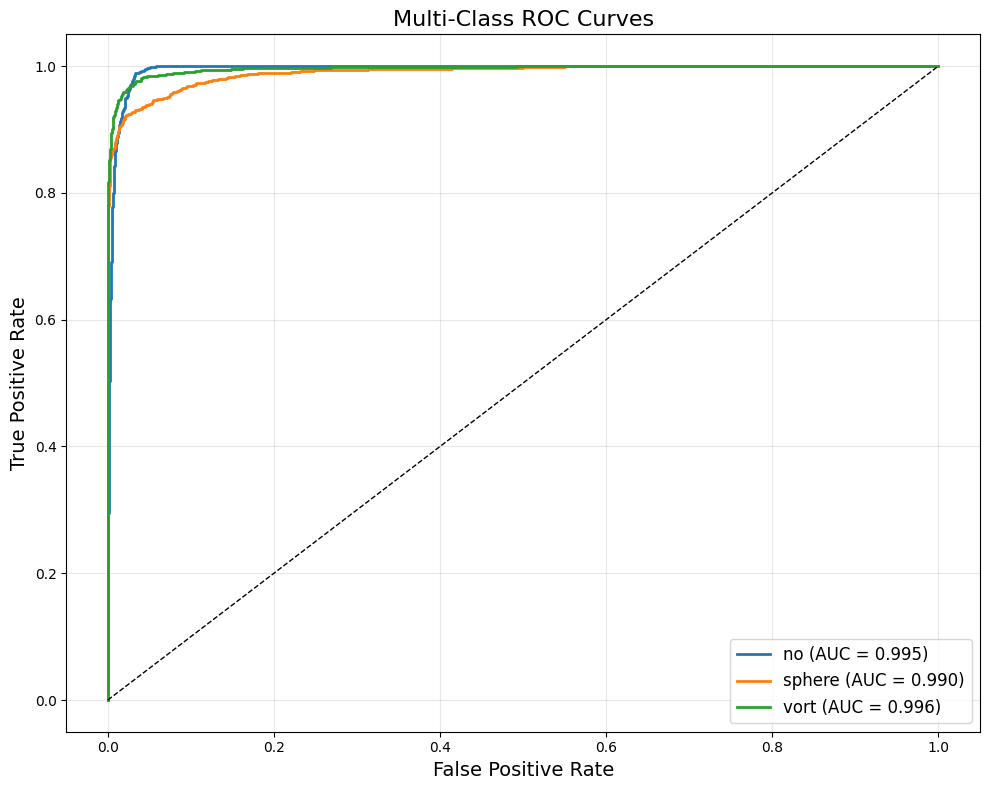


CLASSIFICATION REPORT
              precision    recall  f1-score   support

          no       0.93      0.99      0.96      1274
      sphere       0.96      0.92      0.94      1218
        vort       0.97      0.95      0.96      1258

    accuracy                           0.95      3750
   macro avg       0.95      0.95      0.95      3750
weighted avg       0.95      0.95      0.95      3750



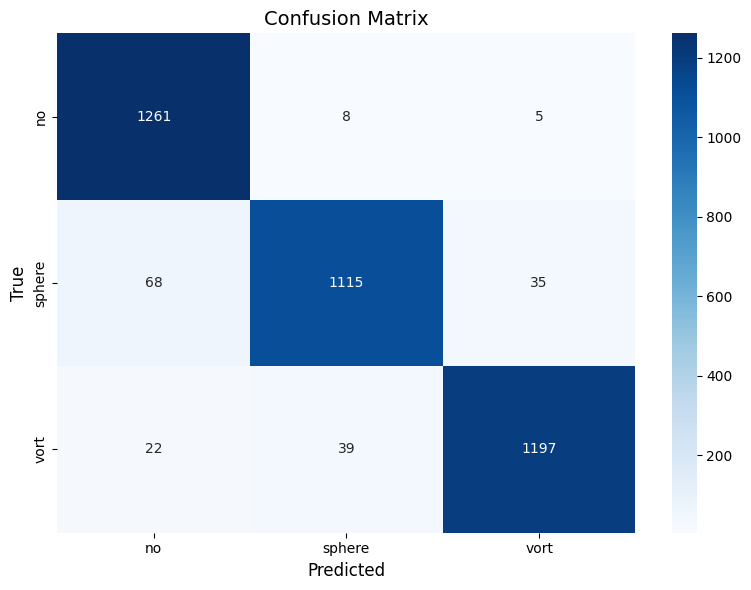

In [ ]:

model.load_state_dict(torch.load('best_model.pth', weights_only=True))
model.eval()

all_probs, all_labels, all_preds = [], [], []

with torch.no_grad():
    for imgs, labels in tqdm(val_loader, desc='Evaluating'):
        imgs = imgs.to(device)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        preds = np.argmax(probs, axis=1)
        all_probs.append(probs)
        all_labels.append(labels.numpy())
        all_preds.append(preds)

all_probs = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)
all_preds = np.concatenate(all_preds)

# AUC Scores
print("=" * 50)
print("AUC SCORES")
print("=" * 50)
print(f"Macro-average OVR ROC-AUC: {roc_auc_score(all_labels, all_probs, average='macro', multi_class='ovr'):.4f}")
print(f"Macro-average OVO ROC-AUC: {roc_auc_score(all_labels, all_probs, average='macro', multi_class='ovo'):.4f}")
print(f"Weighted-average OVR ROC-AUC: {roc_auc_score(all_labels, all_probs, average='weighted', multi_class='ovr'):.4f}")
print(f"Weighted-average OVO ROC-AUC: {roc_auc_score(all_labels, all_probs, average='weighted', multi_class='ovo'):.4f}")

# Per-class ROC Curves
fpr, tpr, roc_auc_dict = {}, {}, {}
for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(all_labels, all_probs[:, i], pos_label=i)
    roc_auc_dict[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for i in range(NUM_CLASSES):
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f'{idx2class[i]} (AUC = {roc_auc_dict[i]:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Multi-Class ROC Curves', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Classification Report
print("\n" + "=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(all_labels, all_preds, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title('Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.show()

## Strategy Discussion  

### Dataset  
The three classes correspond to: `no` (no substructure), `sphere` (subhalo substructure),   
`vort` (vortex substructure). 37,500 images total, balanced across classes.
  
### Architecture  
ResNet18 pretrained on ImageNet, modified for single-channel input. Lightweight yet effective   
for this image classification task. Transfer learning provides strong feature extraction.  
  
### Data Augmentation  
Gravitational lensing images have rotational symmetry, so random flips and 180° rotations   
are physically valid augmentations. Light Gaussian noise adds regularization.  
  
### Data Split  
Combined the provided train and val sets (37,500 total images) and re-split 90:10   
(33,750 train / 3,750 val) as required by the evaluation guidelines, using a fixed   
random seed (42) for reproducibility.  
  
### Training  
- Adam optimizer (lr=3e-4) with CosineAnnealingWarmRestarts scheduler  
- Dropout (0.3) in the classification head  
- CrossEntropyLoss for multi-class classification  
- 25 epochs with best model checkpointing
  
### Normalization  
Per-image min-max normalization to [0, 1] range.